# Keys and Relationships

*Identity, uniqueness, and connections between records.*

A position locates a record in an ordered container. A key identifies a record within a chosen dataset.


## Position and Identity

- List position changes when records are reordered.
- A student ID remains attached to the same student.
- `dict` maps each unique key to one current value.

A dictionary comprehension builds an ID lookup from the student records.

`dict` uses a hash value to locate candidate entries and equality to match the key.


In [1]:
students = [
    {"student_id": "S01", "name": "Mina"},
    {"student_id": "S02", "name": "Joon"},
    {"student_id": "S03", "name": "Sara"},
]
students_by_id = {student["student_id"]: student for student in students}

reordered_students = students.copy()
reordered_students.reverse()

print("Original first ID:", students[0]["student_id"])
print("Reordered first ID:", reordered_students[0]["student_id"])
print("Lookup for S01:", students_by_id["S01"]["name"])


Original first ID: S01
Reordered first ID: S03
Lookup for S01: Mina


Position `0` changes from `S01` to `S03`. Key `S01` still retrieves Mina.


## Sets and Coverage

The student table identifies people; the study records identify student-days within one week.

- Intersection: IDs present in both datasets.
- Set difference: IDs present in only one dataset.
- A set stores distinct IDs, without record multiplicity.

The set comprehension collects student IDs from the study records. Printed sets are sorted for a fixed display order.


In [2]:
study_records = [
    {"student_id": "S01", "day": "Mon", "minutes": 30, "tasks": 2, "score": 70},
    {"student_id": "S02", "day": "Mon", "minutes": 45, "tasks": 3, "score": 80},
    {"student_id": "S01", "day": "Tue", "minutes": 40, "tasks": 4, "score": 75},
]

registered_ids = set(students_by_id)
observed_ids = {record["student_id"] for record in study_records}

print("IDs in both datasets:", sorted(registered_ids & observed_ids))
print("Registered without observations:", sorted(registered_ids - observed_ids))
print("Observed without registration:", sorted(observed_ids - registered_ids))
print("Records and distinct observed students:", len(study_records), len(observed_ids))


IDs in both datasets: ['S01', 'S02']
Registered without observations: ['S03']
Observed without registration: []
Records and distinct observed students: 3 2


`S01` and `S02` have observations; `S03` has none. The three study records refer to two distinct students.


## Unique and Composite Keys

`student_id` is unique in the student table but repeats in the study records. With one record per student-day, `(student_id, day)` identifies an observation.

Assigning an existing dictionary key replaces its value. Indexing the study records by student ID alone retains only the last score for each student.


In [3]:
scores_by_student = {
    record["student_id"]: record["score"] for record in study_records
}
records_by_key = {
    (record["student_id"], record["day"]): record for record in study_records
}

print("Scores indexed only by student:", scores_by_student)
print("ID-only entry count:", len(scores_by_student))
print("Composite-key entry count:", len(records_by_key))
print("S01 Monday score:", records_by_key[("S01", "Mon")]["score"])
print("S01 Tuesday score:", records_by_key[("S01", "Tue")]["score"])


Scores indexed only by student: {'S01': 75, 'S02': 80}
ID-only entry count: 2
Composite-key entry count: 3
S01 Monday score: 70
S01 Tuesday score: 75


The ID-only lookup keeps two entries and overwrites `S01`'s score `70` with `75`. The composite-key lookup preserves all three observations.


## Linking Records by Key

One student can have several study records: a **one-to-many** relationship. The unique student ID lookup supplies a name to each matching observation.

The linked result retains the ID, day, and score, and adds the student's name. All observation IDs are registered in this dataset.


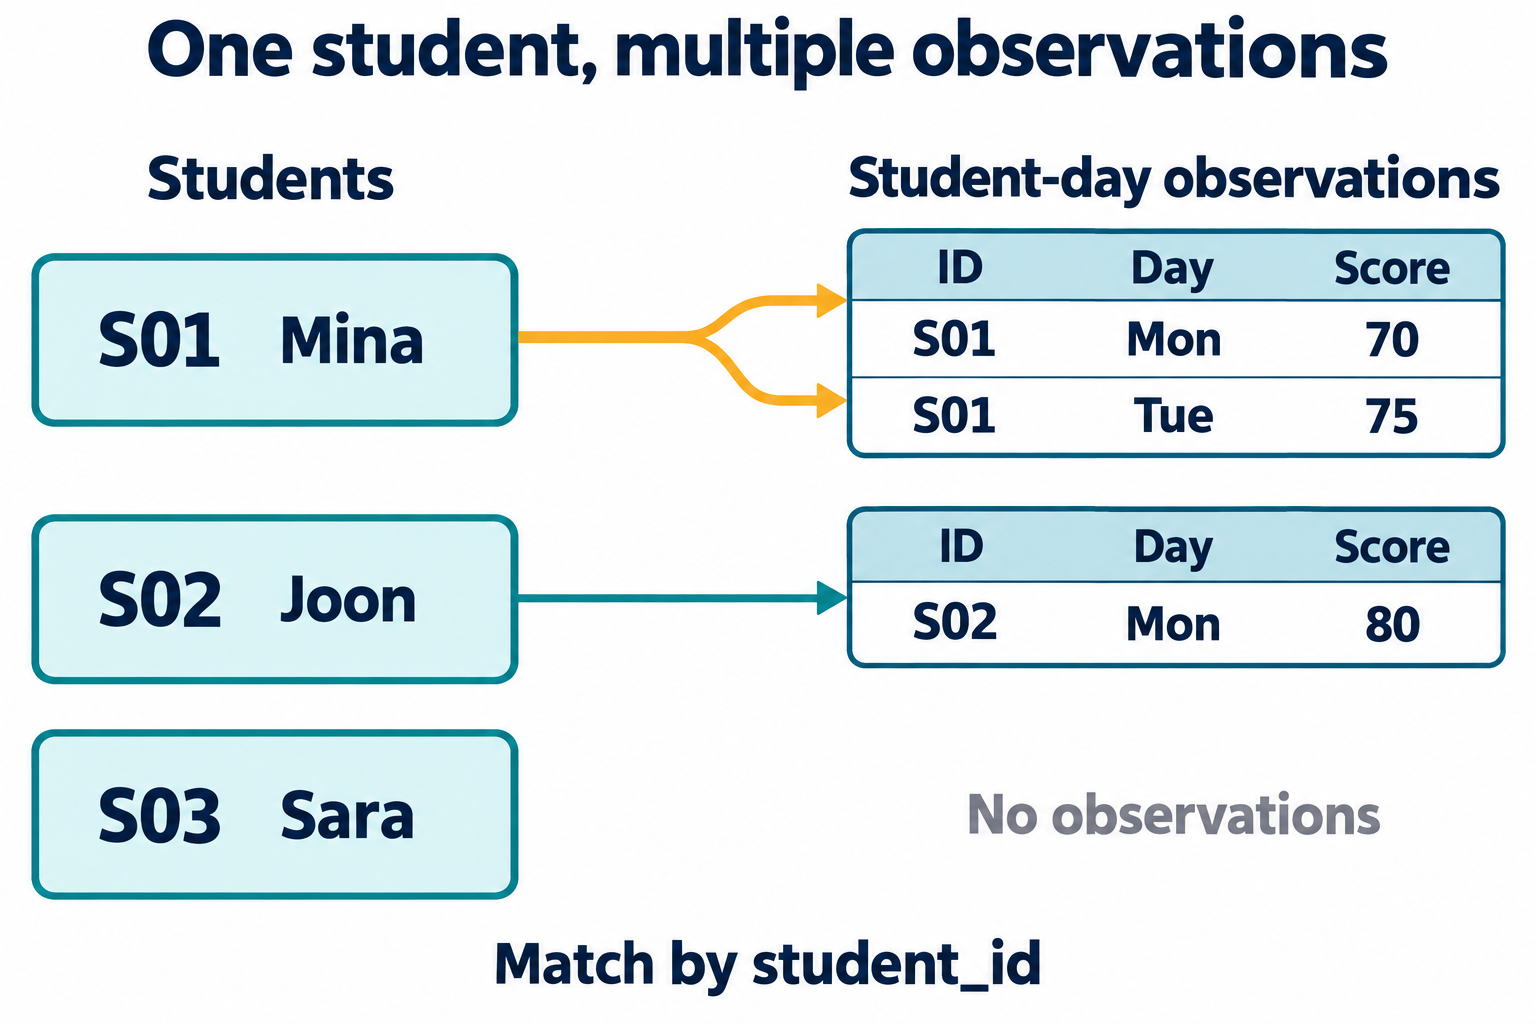

`student_id` connects identity to observations: S01 has two, S02 has one, S03 has none.


In [4]:
linked_records = []
for record in study_records:
    student = students_by_id[record["student_id"]]
    linked_records.append({
        "student_id": record["student_id"],
        "name": student["name"],
        "day": record["day"],
        "score": record["score"],
    })

for record in linked_records:
    print(record)
print("Linked observation count:", len(linked_records))


{'student_id': 'S01', 'name': 'Mina', 'day': 'Mon', 'score': 70}
{'student_id': 'S02', 'name': 'Joon', 'day': 'Mon', 'score': 80}
{'student_id': 'S01', 'name': 'Mina', 'day': 'Tue', 'score': 75}
Linked observation count: 3


The three observations retain their order; Mina's name appears twice. A join that matches every pair would produce four S01 matches if both sides contained two S01 rows: `2 × 2 = 4`.


Key uniqueness depends on the observation unit. Dictionary lookups, set comparisons, and key-based table joins serve different roles: retrieval, coverage, and record linkage.
